<a href="https://colab.research.google.com/github/JuliMiralles/Diplomatura-en-An-lisis-Cuantitativo-y-Machine-Learning-aplicado-al-Riesgo-Financiero/blob/main/Modulo1_Clase1_Ejercicios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo 1 · Clase 1 — Fundamentos del Riesgo de Mercado
## Notebook de ejercicios

Diplomatura en Análisis Cuantitativo y Machine Learning aplicado al Riesgo Financiero  
**Universidad Austral — Sede Rosario**  
Dr. Rodrigo Del Rosso — Director Académico

---

Este notebook acompaña la **Clase 1**, que es conceptual. Su objetivo no es introducir
técnicas nuevas sino dejar resueltos, con código mínimo, los cuatro ejercicios propuestos
al cierre del encuentro, de modo que la Clase 2 comience sobre terreno conocido.

**Regla del curso.** Todo resultado producido con asistencia de inteligencia artificial
debe someterse a los tres controles del protocolo:

1. **Control numérico** — reproducir el resultado por una vía independiente.
2. **Control dimensional y de rango** — verificar unidades, escalas y plausibilidad económica.
3. **Control de supuestos** — enumerar los supuestos y contrastarlos contra los datos.


## 0 · Configuración

In [ ]:
# Configuración del entorno
!pip -q install yfinance arch statsmodels --upgrade

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

SEMILLA = 20260901
rng = np.random.default_rng(SEMILLA)

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({
    "figure.figsize": (11, 3.4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

# Paleta institucional (tomada de la identidad visual de la Universidad Austral)
AZUL, CELESTE, NARANJA, VINO = "#1A25AB", "#67A0D5", "#EB7D0C", "#771C2D"
ROJO, GRIS = "#C41230", "#9A9A9A"
COLORES = {"SPY": AZUL, "TLT": CELESTE, "GLD": NARANJA, "EURUSD": VINO}

import sys
print("Python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 4.1 MB/s eta 0:00:00
Python 3.13.15 | numpy 2.1.3 | pandas 2.2.3


## Ejercicio 1 · Marco conceptual

Elegí una posición real de tu ámbito profesional (o una cartera hipotética) y completá
explícitamente las cuatro definiciones. **Editá la celda siguiente**: el ejercicio es de
redacción, no de cálculo.

| Elemento | Tu respuesta |
|---|---|
| **Cartera** | *(instrumentos y montos)* |
| **Horizonte** | *(1 día, 10 días, 1 mes)* |
| **Factores de riesgo** | *(tasa, FX, acciones, spread, commodities)* |
| **Sensibilidades relevantes** | *(delta, DV01, beta, vega)* |

> Sin estas cuatro definiciones, la expresión «el riesgo de la cartera» no tiene referente.

## Ejercicio 2 · Cálculo

Con precios de cierre diarios de los últimos dos años:

1. Calcular retornos simples y logarítmicos.
2. Estimar la volatilidad anualizada.
3. Verificar numéricamente el error de la regla de la raíz del tiempo a 10 días.

In [ ]:
import yfinance as yf

TICKER = "SPY"          # cambialo por el activo que elegiste
px1 = yf.download(TICKER, start="2024-03-01", end="2026-03-01",
                  auto_adjust=True, progress=False)["Close"].dropna()
px1 = px1.squeeze()
print(f"{TICKER}: {len(px1)} ruedas, de {px1.index.min():%Y-%m-%d} a {px1.index.max():%Y-%m-%d}")

R = px1.pct_change().dropna()                 # retorno simple
r = np.log(px1 / px1.shift(1)).dropna()       # retorno logaritmico

# Control 1 · numerico: ln(1+R) debe coincidir con r hasta precision de maquina
assert np.allclose(np.log1p(R), r), "Las dos definiciones no coinciden"
print("Control numérico superado: r = ln(1 + R)")

print(f"\nDiferencia media |r - R|: {np.abs(r - R).mean():.6f}")
print(f"Diferencia máxima       : {np.abs(r - R).max():.6f}")

SPY: 500 ruedas, de 2024-03-01 a 2026-02-27
Control numérico superado: r = ln(1 + R)

Diferencia media |r - R|: 0.000053
Diferencia máxima       : 0.005157


In [ ]:
sigma_d = r.std(ddof=1)
sigma_a = sigma_d * np.sqrt(252)
print(f"Volatilidad diaria     : {sigma_d:.4%}")
print(f"Volatilidad anualizada : {sigma_a:.2%}")

# ---- Error de la regla de la raiz del tiempo -------------------------------
filas = []
for h in [1, 2, 5, 10, 15, 21, 42, 63]:
    obs = r.rolling(h).sum().dropna().std(ddof=1)   # desvio del retorno acumulado
    esc = sigma_d * np.sqrt(h)                      # regla de la raiz del tiempo
    filas.append({"h (ruedas)": h,
                  "Observado": obs,
                  "Escalado": esc,
                  "Error %": (obs / esc - 1) * 100})

tabla = pd.DataFrame(filas).set_index("h (ruedas)")
display(tabla.style.format({"Observado": "{:.4f}", "Escalado": "{:.4f}", "Error %": "{:+.1f}"}))

e10 = tabla.loc[10, "Error %"]
print(f"\nA 10 días la regla se desvía un {e10:+.1f} % respecto del desvío observado.")
print("Signo positivo: la regla SUBESTIMA. Signo negativo: SOBREESTIMA.")

Volatilidad diaria     : 1.0273%
Volatilidad anualizada : 16.31%


,Observado,Escalado,Error %
h (ruedas),,,
1,0.0103,0.0103,+0.0
2,0.0138,0.0145,-4.7
5,0.0208,0.0230,-9.6
10,0.0269,0.0325,-17.1
15,0.0322,0.0398,-19.1
21,0.0362,0.0471,-23.0
42,0.0503,0.0666,-24.5
63,0.0585,0.0815,-28.2



A 10 días la regla se desvía un -17.1 % respecto del desvío observado.
Signo positivo: la regla SUBESTIMA. Signo negativo: SOBREESTIMA.


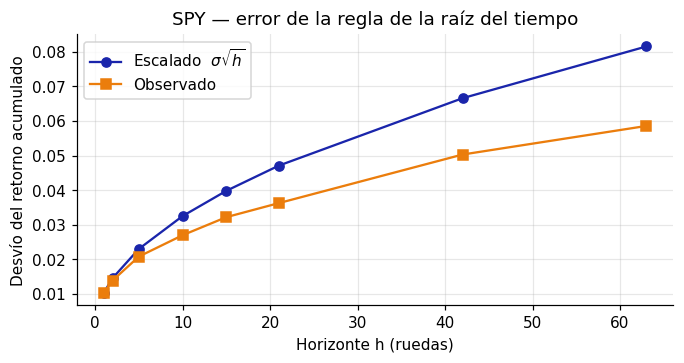

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(tabla.index, tabla["Escalado"], "o-", color=AZUL, label=r"Escalado  $\sigma\sqrt{h}$")
ax.plot(tabla.index, tabla["Observado"], "s-", color=NARANJA, label="Observado")
ax.set_xlabel("Horizonte h (ruedas)")
ax.set_ylabel("Desvío del retorno acumulado")
ax.set_title(f"{TICKER} — error de la regla de la raíz del tiempo")
ax.legend()
plt.show()

### Control 3 · de supuestos

La regla $\sigma(h)=\sigma\sqrt{h}$ requiere que los retornos sean independientes.
El test siguiente verifica si ese supuesto se sostiene sobre tus propios datos.

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_r  = acorr_ljungbox(r,      lags=[10], return_df=True)
lb_r2 = acorr_ljungbox(r ** 2, lags=[10], return_df=True)

print("Ljung-Box sobre r      (H0: sin autocorrelación)")
print(lb_r.to_string(), "\n")
print("Ljung-Box sobre r²     (H0: sin autocorrelación)")
print(lb_r2.to_string())

p2 = lb_r2["lb_pvalue"].iloc[0]
if p2 < 0.05:
    print("\n→ Se rechaza la independencia en r². El supuesto de la regla NO se cumple,")
    print("  y eso explica el error medido más arriba.")

Ljung-Box sobre r      (H0: sin autocorrelación)
    lb_stat  lb_pvalue
10  21.0966     0.0204 

Ljung-Box sobre r²     (H0: sin autocorrelación)
    lb_stat  lb_pvalue
10 109.4047     0.0000

→ Se rechaza la independencia en r². El supuesto de la regla NO se cumple,
  y eso explica el error medido más arriba.


## Ejercicio 3 · Interpretación

Una cartera tiene un **VaR diario al 99 % de 1,2 millones** y un **ES al 97,5 % de 1,5 millones**.

Redactá un párrafo, dirigido a un comité de riesgos no técnico, que explique:

- qué informa cada número;
- qué **no** informa ninguno de los dos;
- por qué el ES es mayor que el VaR pese a tener un nivel de confianza más bajo.

*(Celda de texto: escribí tu respuesta acá.)*

---

**Guía de corrección.** El VaR es un umbral: en el 99 % de los días la pérdida no lo supera.
No dice nada sobre la magnitud de la pérdida cuando el umbral se rompe. El ES responde
exactamente esa pregunta: es el promedio de las pérdidas que superan el cuantil del 97,5 %.
Que el ES sea mayor no es una contradicción, porque promedia toda la cola en lugar de
marcar un punto de corte.

## Ejercicio 4 · Lectura

- Cont, R. (2001), *Empirical properties of asset returns*, secciones 2 y 3.
- McNeil, Frey y Embrechts (2015), *Quantitative Risk Management*, capítulo 2, secciones 2.1 y 2.2.

---

## Cierre

Guardá este notebook en tu Drive. La **Clase 2** parte de la construcción de un panel
multiactivo con SPY, TLT, GLD y EURUSD, y retoma el ejercicio 2 sobre esa cartera.